In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np


In [9]:
#def rmse(pred, true):
#    return np.sqrt(np.mean(np.square(pred-true),axis=1))

def rmse(pred, true,weights=None):
    if weights is not None:
        squared = np.square(pred-true)
        val = np.sqrt(np.average(squared, axis=1, weights=weights))
    else:
        val =np.sqrt(np.mean(np.square(pred-true),axis=1))
    return val 

In [11]:
data_path = '/data/ClimSim/hu_etal2024_data/'
data_path_docker = "/data/climsim-online/scratch/"

ds_grid = xr.open_dataset(data_path+'data_grid/ne4pg2_scrip.nc')
grid_area = ds_grid['grid_area']


ds2 = xr.open_dataset(data_path+'data_grid/E3SM_ML.GNUGPU.F2010-MMF1.ne4pg2_ne4pg2.eam.h0.0001-01.nc')
lat = ds2.lat
lon = ds2.lon
level = ds2.lev.values


In [21]:
pattern = '*.eam.h1.0003-01*.nc'

filenames = data_path_docker + "/example_job_submit_mmf/run/" +pattern
print(filenames)
ds_sp = xr.open_mfdataset(filenames)
print("Shape true:", ds_sp.T.shape)
ds_sp['lev'].attrs['long_name'] = 'hybrid pressure'

nx = ds_sp.T.shape[0]
x = np.arange(nx)


/data/climsim-online/scratch//example_job_submit_mmf/run/*.eam.h1.0003-01*.nc
Shape true: (31, 60, 384)


In [ ]:
filenames = data_path_docker + "/example_job_submit_mmf_0001/run/" +pattern
print(filenames)
ds_sp2 = xr.open_mfdataset(filenames)
print("Shape true:", ds_sp.T.shape)
ds_sp2['lev'].attrs['long_name'] = 'hybrid pressure'

In [22]:
# addSGRU144_meancrmatend_tadv_aaqn_Poldevap_PmaxfromT_loss=ES,h5e-4,rh200,cldpath4e-19,negprec,accumprec1.5e14_mp-1_addq_sedm_condheat_storeprec2e4-pour-posqvqn_NOprevt
label_srnn1= "addSGRU144_meancrmatend_tadv_aaqn_Poldevap_PmaxfromT_loss=ES..NOprevt"
rnn_num = 46128

filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}/run/".format(rnn_num) +pattern
print(filenames)
ds_srnn1 = xr.open_mfdataset(filenames)
ds_srnn1['lev'].attrs['long_name'] = 'hybrid pressure'



/data/climsim-online/scratch//example_job_submit_nnwrapper_v4_rnn_46128/run/*.eam.h1.0003-01*.nc


/tmp/ipykernel_3367754/2182137301.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_srnn1 = xr.open_mfdataset(filenames)


In [21]:
rnn_num = 53099
label_srnn2= "addSGRU128_meancrmatend_tadv_aaqn_Poldevap_PmaxfromT_loss=ES..NOprevt"

pattern = '*.eam.h1.0003-01*.nc'

filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}/run/".format(rnn_num) +pattern
print(filenames)
ds_srnn2 = xr.open_mfdataset(filenames)
ds_srnn2['lev'].attrs['long_name'] = 'hybrid pressure'


/data/climsim-online/scratch//example_job_submit_nnwrapper_v4_rnn_53099/run/*.eam.h1.0003-01*.nc


/tmp/ipykernel_3367754/3696660723.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_srnn2 = xr.open_mfdataset(filenames)


In [19]:
# 23016_LSTM144-144_mp0_2xwcon-xtime,hcon233..12,tr=mixed,val=fullreplay
rnn_num = 23016 # det mixedReplay
label_rnn1 = "23016_LSTM144-144_mp0_2xwcon-xtime,hcon233..12,tr=mixed,val=fullreplay"

pattern = '*.eam.h1.0003-01*.nc'

filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}_1/run/".format(rnn_num) +pattern
print(filenames)
ds_rnn1 = xr.open_mfdataset(filenames)
ds_rnn1['lev'].attrs['long_name'] = 'hybrid pressure'


/data/climsim-online/scratch//example_job_submit_nnwrapper_v4_rnn_23016_1/run/*.eam.h1.0003-01*.nc


/tmp/ipykernel_3367754/622878728.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_rnn1 = xr.open_mfdataset(filenames)


In [23]:
# meancrmatend_aaqn**2_Poldevap_qnmax_PmaxfromT_lossw_loss=h,rh,cldpath,negprec,accumprec1.5e14_mp-1_addq_sedm_condheat_storeprec2e4-evappour-enforceposqvqn_GRU160_NOprevt
label_rnn2 = "GRU160_meancrmatend_aaqn**2_Poldevap_qnmax_PmaxfromT_lossw_loss=h,rh,cldpath,negprec,accumprec1.5e14_mp-1..NOprevt"
rnn_num = 63016 

pattern = '*.eam.h1.0003-01*.nc'

filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}/run/".format(rnn_num) +pattern
print(filenames)
ds_rnn2 = xr.open_mfdataset(filenames)
ds_rnn2['lev'].attrs['long_name'] = 'hybrid pressure'

/data/climsim-online/scratch//example_job_submit_nnwrapper_v4_rnn_63016/run/*.eam.h1.0003-01*.nc


/tmp/ipykernel_3367754/2702916935.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_rnn2 = xr.open_mfdataset(filenames)


In [5]:
ds_rnn1_2.Z500[-1,-1].values

array(5211.1333, dtype=float32)

In [9]:
import numpy as np
T850_ref = ds_sp.T850
Z500_ref = ds_sp.Z500
print(T850_ref.shape)

T850_ref2 = ds_sp2.T850
Z500_ref2 = ds_sp2.Z500
print(T850_ref.shape)

(31, 384)


In [13]:
T850_srnn1 = ds_srnn1.T850
T850_srnn2 = ds_srnn2.T850
T850_rnn1 = ds_rnn1.T850
T850_rnn2 = ds_rnn2.T850

Z500_srnn1 = ds_srnn1.Z500
Z500_srnn2 = ds_srnn2.Z500
Z500_rnn1 = ds_rnn1.Z500
Z500_rnn2 = ds_rnn2.Z500

In [15]:
# https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2023MS004019
# spread is taken as the square roof of the mean ensemble variance
# skill is taken as the ensemble mean RMSE
#T850_srnn1_spread = np.sqrt(np.mean(T850_srnn1_var,axis=1))
#T850_srnn2_spread = np.sqrt(np.mean(T850_srnn2_var,axis=1))
#T850_rnn1_spread = np.sqrt(np.mean(T850_rnn1_var,axis=1))

T850_srnn1_skill = rmse(T850_srnn1, T850_ref)
T850_srnn2_skill = rmse(T850_srnn2, T850_ref)
T850_rnn1_skill   = rmse(T850_rnn1, T850_ref)
T850_rnn2_skill   = rmse(T850_rnn2, Z500_ref)

Z500_srnn1_skill = rmse(Z500_srnn1, Z500_ref)
Z500_srnn2_skill = rmse(Z500_srnn2, Z500_ref)
Z500_rnn1_skill   = rmse(Z500_rnn1, Z500_ref)
Z500_rnn2_skill   = rmse(Z500_rnn2, Z500_ref)

print(T850_srnn1_skill.shape)

nx = T850_rnn1_skill.shape[0]
x = np.arange(nx)

(31,)


In [31]:
grid_area = ds_grid['grid_area']
area_weight = grid_area/np.sum(grid_area)

#lat_1d = ds_sp.lat[0].values
lat_1d = ds_sp.lat.values

def get_tcp_mean(ds, area_weight):
    cld = ds.CLDICE + ds.CLDLIQ
    ps = ds.PS
    p_interface = ds.hyai*ds.P0 + ds.hybi*ds.PS
    p_interface = p_interface.values
    dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
    ggr = 9.81
    tcp = np.sum(cld*dp,axis=1)/9.81
    tcp_mean = np.average(tcp, weights=area_weight,axis=1)
    return tcp_mean


def get_precc_mean(ds, area_weight):
    cld = ds.PRECC[:, :].values + ds.PRECL[:, :].values
    precc = np.average(cld, weights=area_weight,axis=1)
    return precc

area_weight_nh = np.where(lat_1d>30, area_weight, 0)
area_weight_sh = np.where(lat_1d<-30, area_weight, 0)
area_weight_tropics = np.where((lat_1d > -30) & (lat_1d < 30), area_weight, 0)
area_weight_global = area_weight.values

get_mean_function = lambda ds, w: np.average(ds.T[:, -1, :].values, weights=w, axis=1)

In [32]:
area_weight_tropics.sum()

np.float64(0.5170657576093608)

In [22]:
xr.set_options(use_new_combine_kwarg_defaults=True)

rnn_nums = ["23016_1", 
            "51981", 
            "63016",
            "85427",
            "49330_1",
            "1138_ep32_1",
            "46128",
            "53099",
            "13030"]

labels = ["LSTM144-144_mp0_2xwcon-xtime,hcon233..12,tr=mixed,val=fullreplay..PrevTend", 
          "LSTM144-144_seprad96_mp0_2xwcon-xtime,hcon233..12,tr=mixed,val=fullreplay..PrevTend", 
          "PINN_GRU160_aaqn**2...NOprevTend",
          "PINN_LSTM144_aaqn**2...NOprevTend",
          "StochasticLSTM160-96_EnergyScore_prevTend",
          "StochasticLSTM144-96_CRPS-sumvare_prevTend",
          "PINN_StochasticGRU144_EnergyScore...NOprevTend",
          "PINN_StochasticGRU128_EnergyScore...NOprevTend",
          "PINN_StochasticGRUdown128_EnergyScore...NOprevTend"]


var = "T850"

colors = ["black","blue","darkblue","green",   "orange", "lightgreen", "red", "magenta", "darkorange"]
linestyles = ["-","-","--", "--", "-","-","--","--","--"]

use_weights = True
            
def plot_skill(varname, rnn_modelnums, labels, colors, weights ):
    var_true = ds_sp.variables[varname]
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 7))
    
    i = 0
    for rnn_num in rnn_nums:
        pattern = '*.eam.h1.0003-01*.nc'

        filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}/run/".format(rnn_num) +pattern
        ds_rnn = xr.open_mfdataset(filenames)
        ds_rnn['lev'].attrs['long_name'] = 'hybrid pressure'   
        var_pred = ds_rnn.variables[varname]
        if use_weights: 
            #var_pred = 384 * var_pred * weights
            mem_skill = rmse(var_pred.values, var_true.values, weights)
        else:
            mem_skill = rmse(var_pred, var_true)
        ax.plot(x, mem_skill,  color=colors[i], label=labels[i]+", mem RMSE", linestyle=linestyles[i])

        i = i + 1 
    
    ax.legend()
    ax.grid(True)
    ax.set_title('RMSE, {} '.format(varname))
    ax.set_ylabel('RMSE')
    ax.set_xlabel("days")
    ax.set_xlim([0,30])


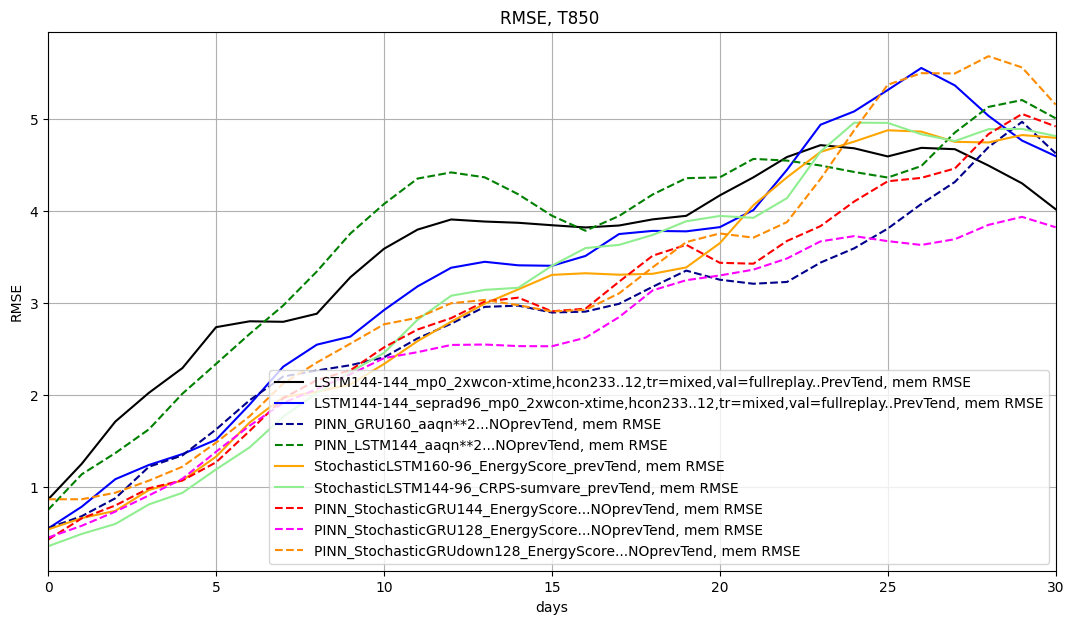

In [23]:
plot_skill(var, rnn_nums, labels, colors, area_weight_global)

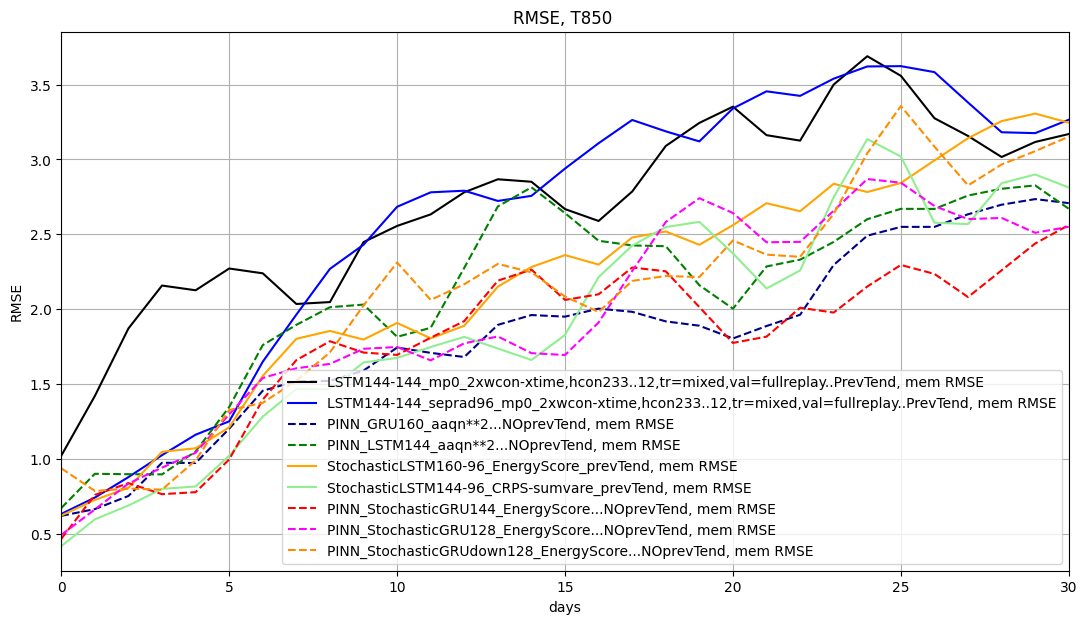

In [33]:
plot_skill(var, rnn_nums, labels, colors, area_weight_tropics)


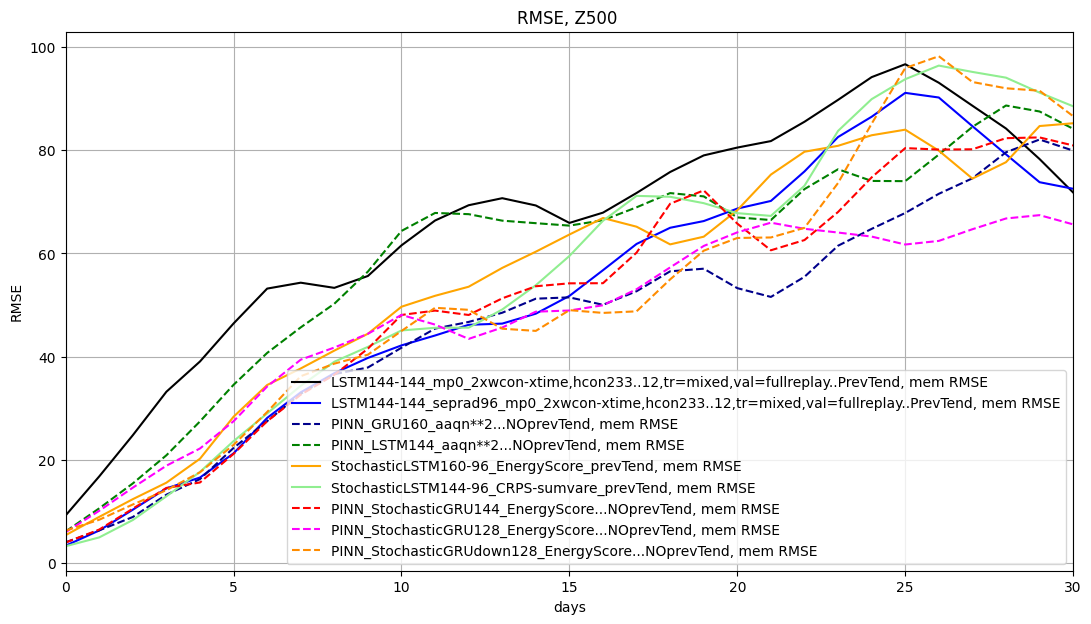

In [34]:
var = "Z500"
plot_skill(var, rnn_nums, labels, colors, area_weight_global)


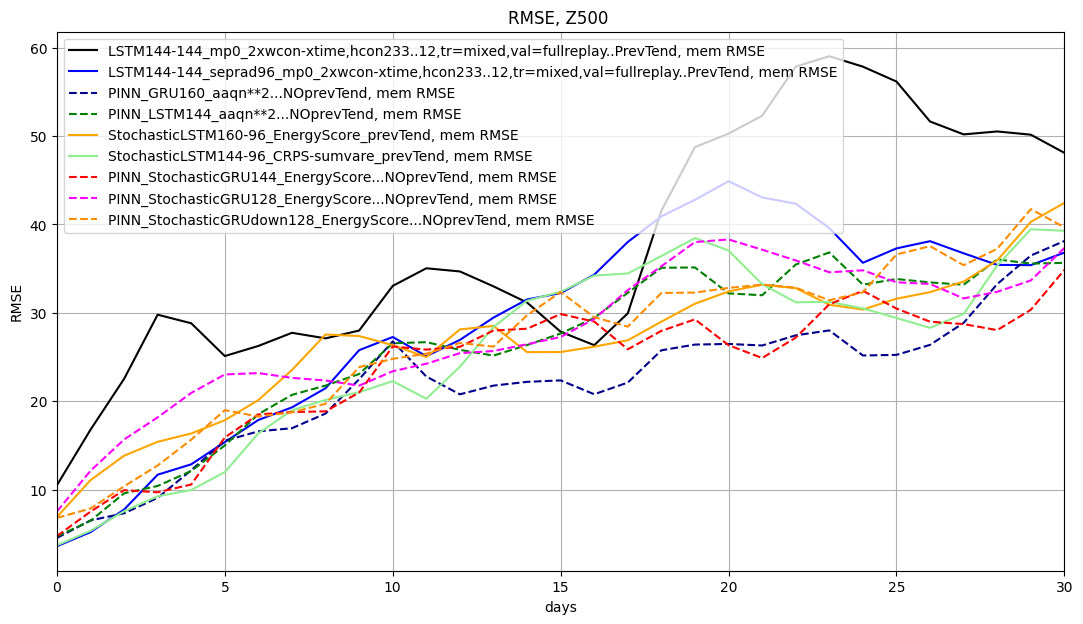

In [35]:
plot_skill(var, rnn_nums, labels, colors, area_weight_tropics)


In [79]:
var_true = ds_sp.variables["T850"]
print(var_true.shape, var_true.values.mean())

(31, 384) 278.34445


In [101]:
np.reshape(weights.values,((1,-1)))

array([[0.00218431, 0.00244333, 0.00244333, 0.00268089, 0.0023245 ,
        0.00239791, 0.00266064, 0.00272638, 0.00239791, 0.0023245 ,
        0.00272638, 0.00266064, 0.00244333, 0.00218431, 0.00268089,
        0.00244333, 0.0023245 , 0.00266064, 0.00239791, 0.00272638,
        0.00280893, 0.00292484, 0.00292484, 0.00303731, 0.00292484,
        0.00280893, 0.00303731, 0.00292484, 0.00266064, 0.0023245 ,
        0.00272638, 0.00239791, 0.00239791, 0.00272638, 0.0023245 ,
        0.00266064, 0.00292484, 0.00303731, 0.00280893, 0.00292484,
        0.00303731, 0.00292484, 0.00292484, 0.00280893, 0.00272638,
        0.00239791, 0.00266064, 0.0023245 , 0.00244333, 0.00268089,
        0.00218431, 0.00244333, 0.00266064, 0.00272638, 0.0023245 ,
        0.00239791, 0.00272638, 0.00266064, 0.00239791, 0.0023245 ,
        0.00268089, 0.00244333, 0.00244333, 0.00218431, 0.00218431,
        0.00244333, 0.00244333, 0.00268089, 0.0023245 , 0.00239791,
        0.00266064, 0.00272638, 0.00239791, 0.00

In [115]:
var_true.values.shape

(31, 384)

In [116]:
weights.shape

(384,)

Text(0.5, 0, 'days')

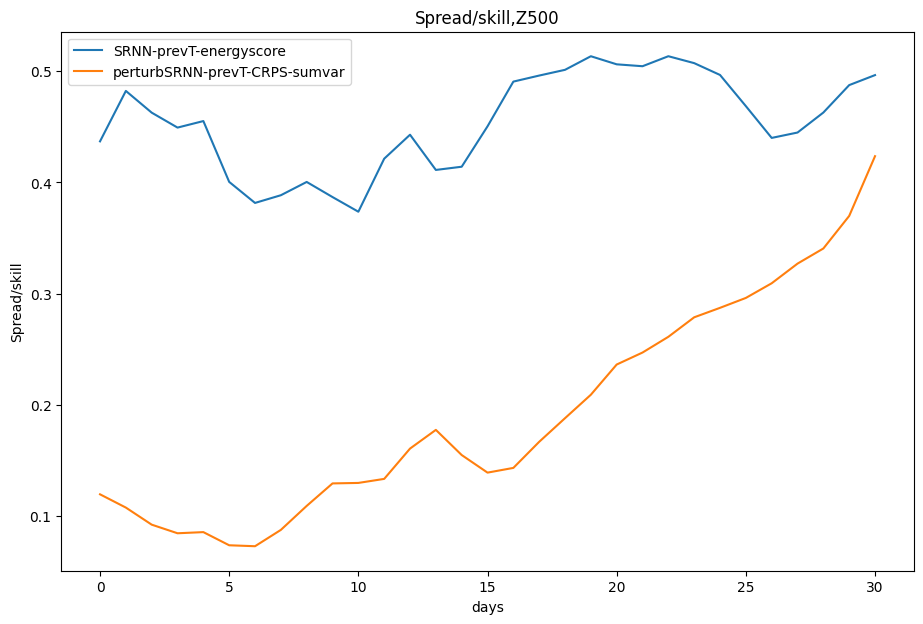

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 7))
ax.plot(x,Z500_srnn1_spread/Z500_srnn1_skill,label=label_srnn1)
ax.plot(x,Z500_srnn2_spread/Z500_srnn2_skill,label=label_srnn2)
ax.legend()
ax.set_title('RMSE,Z500')
ax.set_ylabel('RMSE')
ax.set_xlabel("days")

/tmp/ipykernel_459865/1118041018.py:24: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_rnn_1 = xr.open_mfdataset(filenames)
/tmp/ipykernel_459865/1118041018.py:29: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_rnn_2 = xr.open_mfdataset(filenames)
/tmp/ipykernel_459865/1118041018.py:46: FutureWarning: In a 

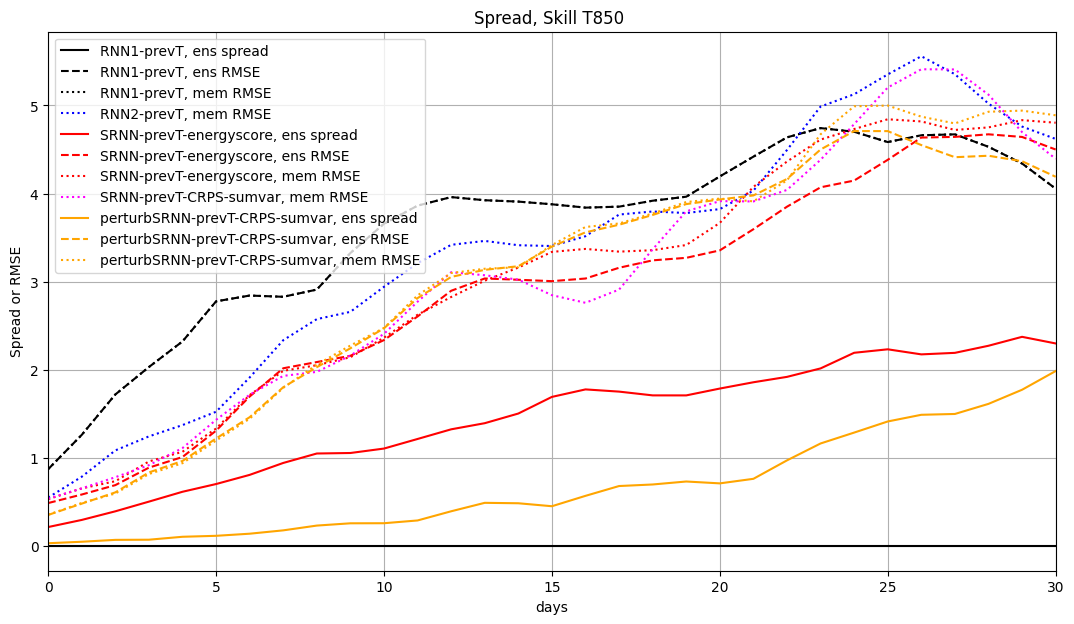

In [46]:
var = "T850"

rnn_nums = ["23016", # 23016_LSTM144-144_mp0_2xwcon-xtime,hcon233..12,tr=mixed,val=fullreplay
            "51981", # cont_LSTM144-144-seprad96_mp0_2xwcon-xtime,hcon233..12,tr=mixed,val=fullreplay,hcon6e-6_wcon2e7_wbias4e-1 
            "49330", # ens4_srules-esfair_partstochastic_SLSTM4-160-96_..122..3_hcon1e-3_wcon1e10(tstep=1)  
            "26724", # ens3_srules-CRPS-sumvar_partiallystochastic_SLSTM4-144-96_..123344..10_hcon2e-3_TSTEPwcon5e9    no wcon, very low offline heating bias
            "1138_ep32"] # fulldata_ens3_srules-CRPS-sumvar_perturbSGRU4-128-12822..3_hcon2e-3_wcon2e10_wprec6e16_wbias5e3 

labels = ["RNN1-prevT", "RNN2-prevT", "SRNN-prevT-energyscore", "SRNN-prevT-CRPS-sumvar","perturbSRNN-prevT-CRPS-sumvar"]
ensemble = [True,False,True,False,True]
colors = ["black","blue","red", "magenta","orange"]

def plot_spreadskill(varname, rnn_modelnums, labels, ensemble, colors):
    var_true = ds_sp.variables[varname]
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(13, 7))
    
    i = 0
    for rnn_num in rnn_nums:
        pattern = '*.eam.h1.0003-01*.nc'
    
        if ensemble[i]:
            filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}/run/".format(rnn_num) +pattern
            ds_rnn = xr.open_mfdataset(filenames)
            ds_rnn['lev'].attrs['long_name'] = 'hybrid pressure'
            var_pred = ds_rnn.variables[varname]
    
            filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}_2/run/".format(rnn_num) +pattern
            ds_rnn_2 = xr.open_mfdataset(filenames)
            ds_rnn_2['lev'].attrs['long_name'] = 'hybrid pressure'
    
            ds_rnn_ens = xr.concat([ds_rnn, ds_rnn_2], dim="ens")
            ens_var = np.var(ds_rnn_ens.variables[varname],axis=0)
            ens_mean = np.mean(ds_rnn_ens.variables[varname],axis=0)
    
            ens_spread = np.sqrt(np.mean(ens_var,axis=1))        
            ens_skill = rmse(ens_mean, var_true)
            mem_skill = rmse(var_pred, var_true)
    
            ax.plot(x, ens_spread, color=colors[i], label=labels[i]+", ens spread", linestyle="-")
            ax.plot(x, ens_skill,  color=colors[i], label=labels[i]+", ens RMSE", linestyle="--")
            ax.plot(x, mem_skill,  color=colors[i], label=labels[i]+", mem RMSE", linestyle=":")
            
        else:
            filenames = data_path_docker + "/example_job_submit_nnwrapper_v4_rnn_{}/run/".format(rnn_num) +pattern
            ds_rnn = xr.open_mfdataset(filenames)
            ds_rnn['lev'].attrs['long_name'] = 'hybrid pressure'   
            var_pred = ds_rnn.variables[varname]
    
            mem_skill = rmse(var_pred, var_true)
            ax.plot(x, mem_skill,  color=colors[i], label=labels[i]+", mem RMSE", linestyle=":")
    
        i = i + 1 
    
    ax.legend()
    ax.grid(True)
    ax.set_title('Spread, Skill {} '.format(varname))
    ax.set_ylabel('Spread or RMSE')
    ax.set_xlabel("days")
    ax.set_xlim([0,30])

plot_spreadskill(var, rnn_nums, labels, ensemble, colors)


/tmp/ipykernel_459865/1118041018.py:24: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_rnn_1 = xr.open_mfdataset(filenames)
/tmp/ipykernel_459865/1118041018.py:29: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_rnn_2 = xr.open_mfdataset(filenames)
/tmp/ipykernel_459865/1118041018.py:46: FutureWarning: In a 

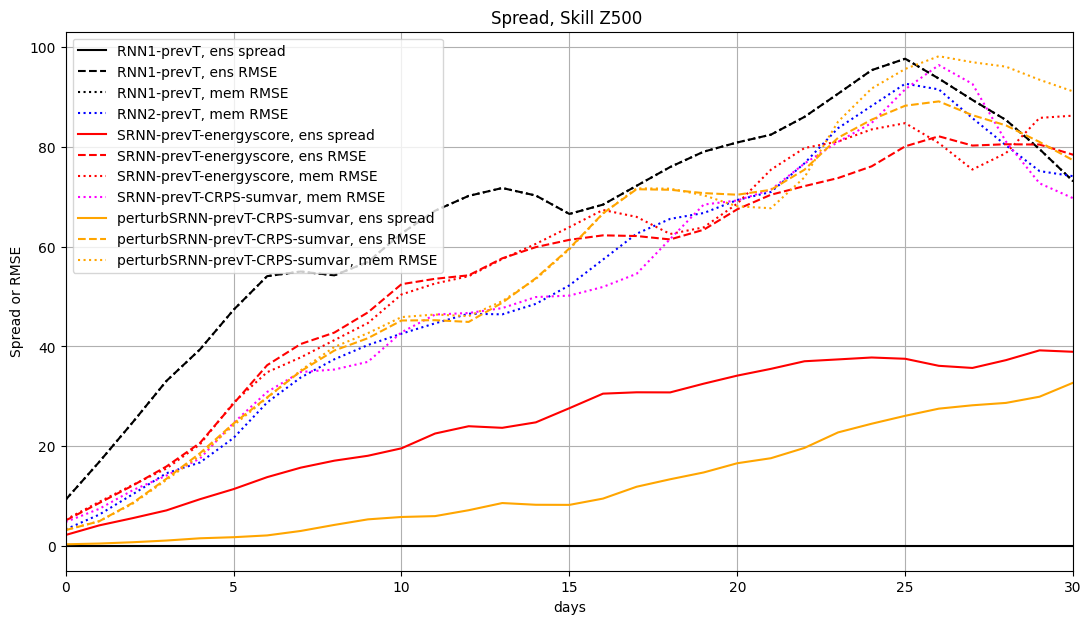

In [47]:
var = "Z500"

plot_spreadskill(var, rnn_nums, labels, ensemble, colors)


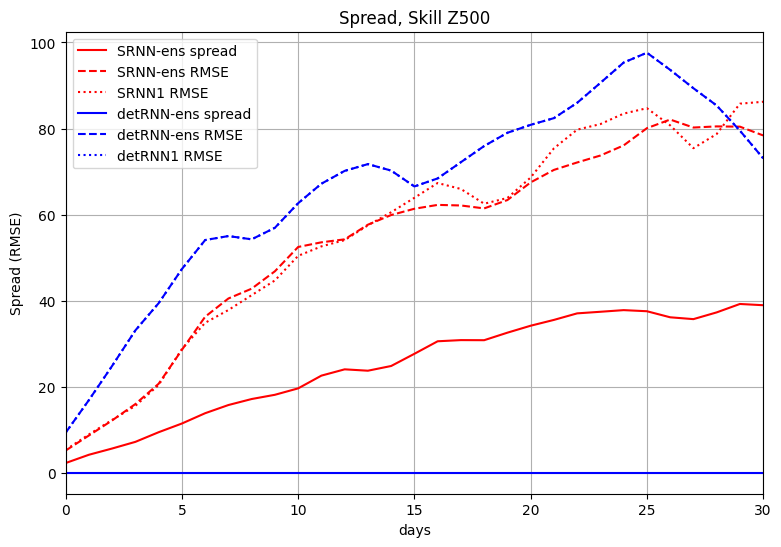

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(9,6))

models = ["SRNN, detRNN"]
colors = ["red", "blue"]
i = 0
for vartuple in [(Z500_spread,Z500_skill,Z500_skill_srnn1),(Z500_spread_det, Z500_skill_det, Z500_skill_det1)]:
    ensspread, ensskill, memskill = vartuple
    ax.plot(x, ensspread, color=colors[i], linestyle="-")
    ax.plot(x, ensskill,  color=colors[i], linestyle="--")
    ax.plot(x, memskill,  color=colors[i], linestyle=":")
    i = i + 1 

ax.grid(True)
ax.set_title('Spread, Skill Z500')
ax.set_ylabel('Spread (RMSE)')
ax.set_xlabel("days")
ax.set_xlim([0,30])
ax.legend(["SRNN-ens spread","SRNN-ens RMSE", "SRNN1 RMSE", "detRNN-ens spread", "detRNN-ens RMSE","detRNN1 RMSE"])
#ax.legend(["SRNN-ens spread","SRNN-mean skill", "SRNN1 skill", "SRNN2 skill", "RNN skill"])

Text(0.5, 0, 'days')

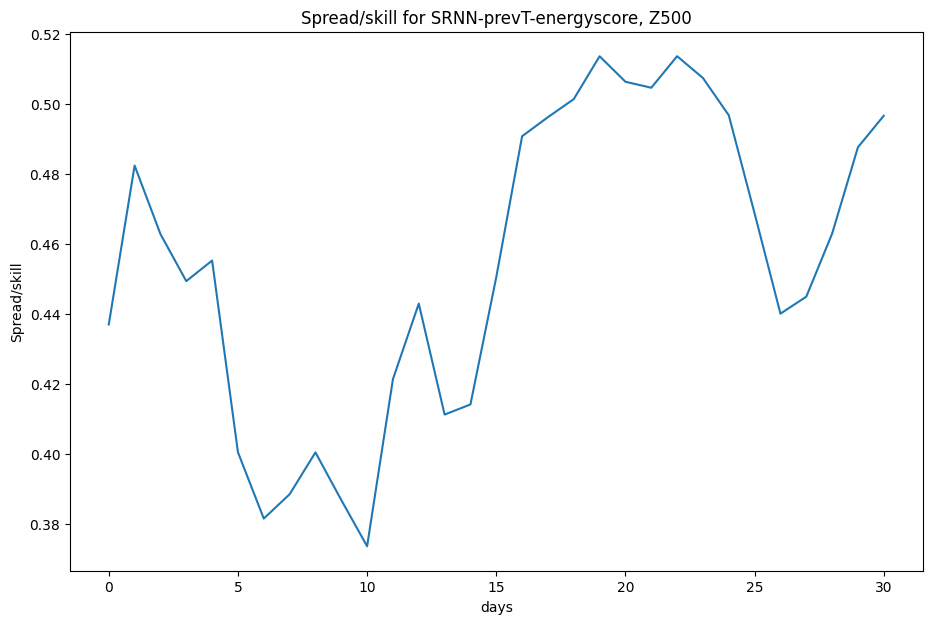

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 7))
ax.plot(x,Z500_spread/Z500_skill)
ax.set_title('Spread/skill for SRNN-prevT-energyscore, Z500')
ax.set_ylabel('Spread/skill')
ax.set_xlabel("days")

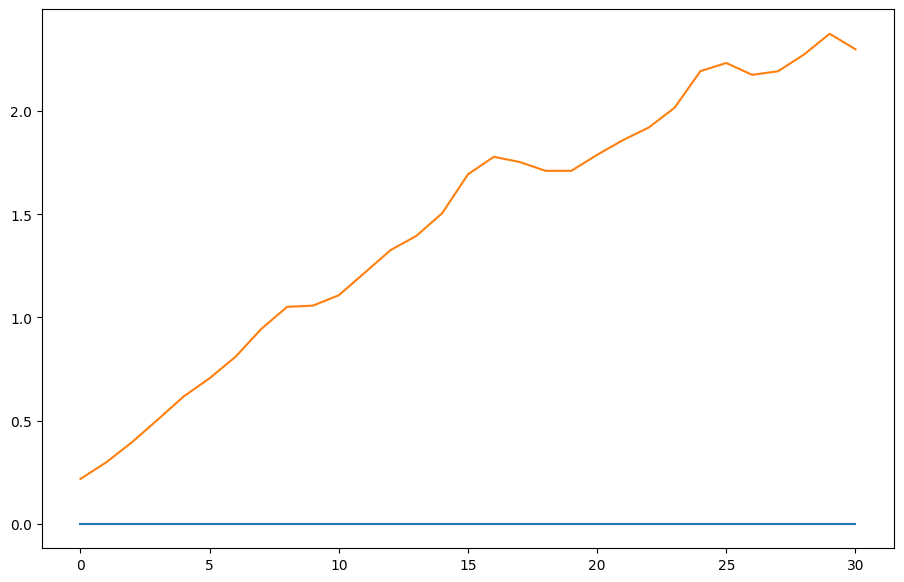

In [62]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 7))
ax.plot(x,Z500_spread, x,Z500_spread_srnn)